# AlexNet — Feature Extraction & Invariance Analysis (raw / no pooling)

Same as `invariance_AlexNet.ipynb` but features are **not** globally average-pooled.
Each `(B, C, H, W)` activation map is flattened to `(B, C×H×W)` before computing
the representation similarity matrix.

Feature of each conv = **input to the next conv** (or classifier):

| Name | Hook idx | Layer | Meaning |
|------|----------|-------|---------|
| C1 | 2 | MaxPool | after relu+pool → input to Conv2 |
| C2 | 5 | MaxPool | after relu+pool → input to Conv3 |
| C3 | 7 | ReLU | after relu → input to Conv4 |
| C4 | 9 | ReLU | after relu → input to Conv5 |
| C5 | 12 | MaxPool | after relu+pool → input to classifier |

In [1]:
import os, sys
import torch
import numpy as np
from PIL import Image
import torchvision.models as models
import torchvision.transforms as T
from collections import OrderedDict
import matplotlib.pyplot as plt

sys.path.append('../utils')
import util

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Load AlexNet

In [2]:
weights = models.AlexNet_Weights.IMAGENET1K_V1
model = models.alexnet(weights=weights).to(device)
model.eval()

conv_defs = [
    ('C1',  2),   # MaxPool — input to Conv(3)
    ('C2',  5),   # MaxPool — input to Conv(6)
    ('C3',  7),   # ReLU   — input to Conv(8)
    ('C4',  9),   # ReLU   — input to Conv(10)
    ('C5', 12),   # MaxPool — input to classifier
]

print('AlexNet conv layers (hook at input to next conv):')
for cname, idx in conv_defs:
    print(f'  {cname}: features[{idx}] = {model.features[idx].__class__.__name__}')

AlexNet conv layers (hook at input to next conv):
  C1: features[2] = MaxPool2d
  C2: features[5] = MaxPool2d
  C3: features[7] = ReLU
  C4: features[9] = ReLU
  C5: features[12] = MaxPool2d


## Load & preprocess images

In [3]:
from scipy.io import loadmat

datapath = '../data'
mat = loadmat(os.path.join(datapath, 'miguel_passive8x4.mat'))
img = mat['img'].astype(np.float32)
images_gray = np.transpose(img, (2, 0, 1))   # (32, 150, 600)
print('images_gray:', images_gray.shape, '  range:', images_gray.min(), images_gray.max())

nimg = len(images_gray)
print(f'nimg={nimg}  (8 categories x 4 instances)')

images_rgb = [Image.fromarray(images_gray[i]).convert('RGB') for i in range(nimg)]

images_gray: (32, 150, 600)   range: 0.0 255.0
nimg=32  (8 categories x 4 instances)


In [4]:
mean_norm = (0.485, 0.456, 0.406)
std_norm  = (0.229, 0.224, 0.225)

transform = T.Compose([
    T.Resize((64, 264)),
    T.ToTensor(),
    T.Normalize(mean=mean_norm, std=std_norm),
])

x = torch.stack([transform(im) for im in images_rgb], dim=0).to(device)
print('Input batch:', x.shape, x.dtype)

Input batch: torch.Size([32, 3, 64, 264]) torch.float32


## Register hooks and extract features

In [5]:
feats = OrderedDict()
handles = []

def make_hook(store, name):
    def _h(m, inp, out):
        store[name] = out.detach().cpu().clone()
    return _h

for cname, ri in conv_defs:
    handles.append(model.features[ri].register_forward_hook(make_hook(feats, cname)))

with torch.no_grad():
    _ = model(x)

for h in handles:
    h.remove()

print('Captured layers and shapes:')
for k, v in feats.items():
    print(f'  {k}: {tuple(v.shape)}')

Captured layers and shapes:
  C1: (32, 64, 7, 32)
  C2: (32, 192, 3, 15)
  C3: (32, 384, 3, 15)
  C4: (32, 256, 3, 15)
  C5: (32, 256, 1, 7)


## Flatten spatial dims → `(B, C×H×W)` feature vectors

No pooling — the full spatial layout is preserved in the flattened vector.

In [6]:
flat = OrderedDict()
for name, t in feats.items():
    flat[name] = t.reshape(t.shape[0], -1).numpy()   # (B, C*H*W)

print('Flat shapes (B, C*H*W):')
for k, v in flat.items():
    print(f'  {k}: {v.shape}')

Flat shapes (B, C*H*W):
  C1: (32, 14336)
  C2: (32, 8640)
  C3: (32, 17280)
  C4: (32, 11520)
  C5: (32, 1792)


## Compute invariance

In [7]:
keys = list(flat.keys())
arr = np.empty(len(keys), dtype=object)
for i, k in enumerate(keys):
    arr[i] = flat[k]   # (32, D)

rep_mtx  = util.compute_model_rep_mtx(arr)
invar_df = util.compute_pair_inv_model(rep_mtx)
print('Invariance computed.')

Invariance computed.


## Summarise (mean ± std per layer) and save

In [8]:
n_layers = len(keys)
inv_values = np.array([
    invar_df[invar_df['layer'] == il]['pair_invariance'].values
    for il in range(n_layers)
])   # (n_layers, 28)

inv_summary = {
    'layer_names': keys,
    'values': inv_values,
}

os.makedirs('outputs', exist_ok=True)
np.save('outputs/alexnet_inv_per_conv_raw.npy', inv_summary, allow_pickle=True)
print('Invariance values saved.')

mean = inv_values.mean(axis=1)
sem  = inv_values.std(axis=1) / np.sqrt(inv_values.shape[1])
print('\nPer-conv mean ± SEM invariance:')
for name, m, s in zip(keys, mean, sem):
    print(f'  {name}: {m:.4f} ± {s:.4f}')

Invariance values saved.

Per-conv mean ± SEM invariance:
  C1: 0.0089 ± 0.0019
  C2: 0.0503 ± 0.0065
  C3: 0.1180 ± 0.0119
  C4: 0.1936 ± 0.0166
  C5: 0.2179 ± 0.0190


## Save flat features

In [9]:
arr_save = np.empty(len(flat), dtype=object)
for i, v in enumerate(flat.values()):
    arr_save[i] = v
np.save('outputs/alexnet_flat_features_conv.npy', arr_save, allow_pickle=True)
print('saved: outputs/alexnet_flat_features_conv.npy')

saved: outputs/alexnet_flat_features_conv.npy


## Plot invariance across conv layers

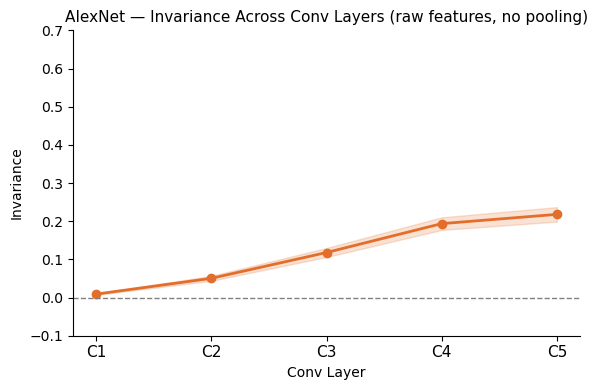

In [10]:
values = inv_summary['values']
mean   = values.mean(axis=1)
sem    = values.std(axis=1) / np.sqrt(values.shape[1])
x      = np.arange(len(keys))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, mean, 'o-', color='#e36e2b', lw=2, ms=6)
ax.fill_between(x, mean - sem, mean + sem, alpha=0.2, color='#e36e2b')
ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_ylim(-0.1, 0.7)
ax.set_xticks(x)
ax.set_xticklabels(keys, fontsize=11)
ax.set_xlabel('Conv Layer')
ax.set_ylabel('Invariance')
ax.set_title('AlexNet — Invariance Across Conv Layers (raw features, no pooling)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/alexnet_invariance_raw.png', dpi=300, bbox_inches='tight')
plt.show()